# EDA — Proyecto Predicción Mundial 2026
Análisis exploratorio de datos sobre los 4 datasets del proyecto:
- **Transfermarkt**: valor de mercado de las selecciones
- **Eliminatorias conjuntas**: rendimiento en clasificación al Mundial 2026
- **Ranking FIFA histórico**: posición FIFA 1993–2026
- **Historial mundialista**: estadísticas acumuladas en Copas del Mundo 1930–2022

## 1. Carga de datos e inspección general

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = 'tab10'
CONF_PALETTE = {
    'UEFA': '#4C72B0', 'AFC': '#DD8452', 'CONMEBOL': '#55A868',
    'CONCACAF': '#C44E52', 'CAF': '#8172B2', 'OFC': '#937860'
}
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

In [12]:
df_transfer  = pd.read_csv('./Data/transfermarkt_selecciones.csv')
df_elimns    = pd.read_csv('./Data/Eliminatorias/eliminatorias_conjuntas.csv')
df_ranking   = pd.read_csv('./Data/ranking_mundial_2026_v2.csv').drop(columns=['team_name_es'])
df_historial = pd.read_csv('./Data/WorldCupHistory/historial_mundialista.csv')

print('Datasets cargados:')
print(f'  df_transfer  : {df_transfer.shape}')
print(f'  df_elimns    : {df_elimns.shape}')
print(f'  df_ranking   : {df_ranking.shape}')
print(f'  df_historial : {df_historial.shape}')

Datasets cargados:
  df_transfer  : (70, 8)
  df_elimns    : (64, 15)
  df_ranking   : (2176, 7)
  df_historial : (64, 13)


In [13]:
def inspect_df(df, name):
    sep = "=" * 60
    print(sep)
    print(f"  {name}  —  {df.shape[0]} filas x {df.shape[1]} columnas")
    print(sep)
    display(df.head(3))
    print()
    print("Tipos:")
    display(df.dtypes.to_frame("dtype").T)
    print()
    print("Estadisticas numericas:")
    display(df.describe())
    nulls = df.isnull().sum()
    nulls_pct = (nulls / len(df) * 100).round(1)
    null_info = pd.DataFrame({"nulos": nulls, "pct": nulls_pct})
    if nulls.sum() > 0:
        print()
        print("Valores nulos:")
        display(null_info[null_info["nulos"] > 0])
    else:
        print("Sin valores nulos.")
    dups = df.duplicated().sum()
    print(f"Filas duplicadas: {dups}")

inspect_df(df_transfer,  "df_transfer  (Transfermarkt)")
inspect_df(df_elimns,    "df_elimns    (Eliminatorias)")
inspect_df(df_ranking,   "df_ranking   (Ranking FIFA)")
inspect_df(df_historial, "df_historial (Historial Mundialista)")

  df_transfer  (Transfermarkt)  —  70 filas x 8 columnas


,rank_tm,country_name_tm,country_code,confederation,members,avg_age,market_value_eur_m,avg_player_value_eur_m
0,1,England,ENG,UEFA,25,26.900,1300.000,51.800
1,2,France,FRA,UEFA,25,26.800,1290.000,51.500
2,3,Spain,ESP,UEFA,27,27.300,1150.000,42.670



Tipos:


,rank_tm,country_name_tm,country_code,confederation,members,avg_age,market_value_eur_m,avg_player_value_eur_m
dtype,int64,object,object,object,int64,float64,float64,float64



Estadisticas numericas:


...


Tipos:


,country_code,nombre_completo,status,pj,g,e,p,gf,gc,dg,gf_per_game,gc_per_game,win_pct
dtype,object,object,object,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64



Estadisticas numericas:


,pj,g,e,p,gf,gc,dg,gf_per_game,gc_per_game,win_pct
count,64.000,64.000,64.000,64.000,64.000,64.000,64.000,64.000,64.000,64.000
mean,25.047,10.328,5.594,9.125,36.234,33.547,2.688,0.997,1.395,0.256
std,27.609,15.881,6.062,7.544,51.280,31.672,27.291,0.578,0.861,0.191
min,0.000,0.000,0.000,0.000,0.000,0.000,-39.000,0.000,0.000,0.000
25%,4.750,0.000,0.750,3.000,3.750,9.750,-8.000,0.667,1.094,0.000
50%,16.500,4.000,4.000,7.500,15.000,24.500,-2.000,1.055,1.403,0.255
75%,35.500,12.250,8.000,13.500,44.000,49.250,0.000,1.425,1.729,0.410
max,114.000,76.000,22.000,28.000,237.000,130.000,129.000,2.079,4.667,0.667


Sin valores nulos.
Filas duplicadas: 0


## 2. EDA — Transfermarkt (Valor de mercado)

In [14]:
print('Estadísticas descriptivas — variables clave:')
display(df_transfer[['market_value_eur_m','avg_player_value_eur_m','avg_age','members']].describe())

Estadísticas descriptivas — variables clave:


,market_value_eur_m,avg_player_value_eur_m,avg_age,members
count,69.000,58.000,70.000,70.000
mean,270.113,12.401,27.226,25.843
std,310.321,12.672,1.154,3.374
min,5.300,1.090,24.100,14.000
25%,44.250,3.760,26.525,24.000
50%,164.350,8.710,27.250,26.000
75%,370.800,15.308,28.075,28.000
max,1300.000,51.800,29.400,36.000


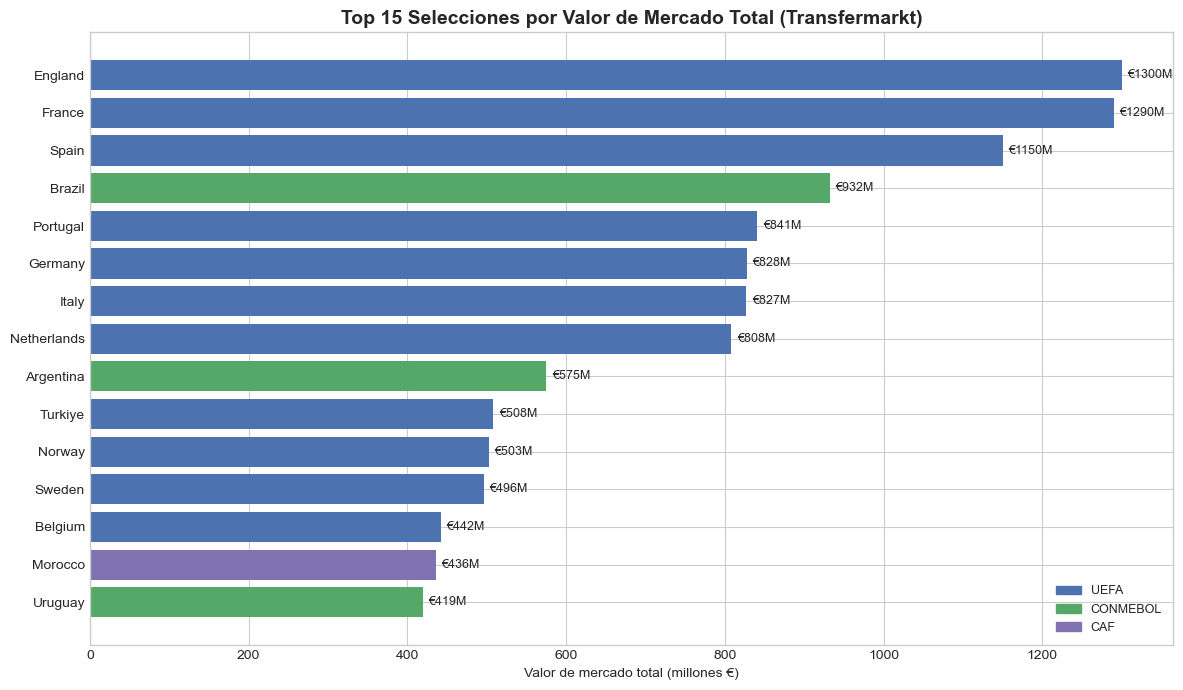

In [15]:
top15_mv = df_transfer.nlargest(15, 'market_value_eur_m').sort_values('market_value_eur_m')
colors   = [CONF_PALETTE.get(c, '#888') for c in top15_mv['confederation']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_mv['country_name_tm'], top15_mv['market_value_eur_m'], color=colors)
ax.bar_label(bars, fmt='€%.0fM', padding=4, fontsize=9)
ax.set_xlabel('Valor de mercado total (millones €)')
ax.set_title('Top 15 Selecciones por Valor de Mercado Total (Transfermarkt)', fontsize=14, fontweight='bold')
# Leyenda confederaciones
from matplotlib.patches import Patch
legend_els = [Patch(color=v, label=k) for k,v in CONF_PALETTE.items() if k in top15_mv['confederation'].values]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

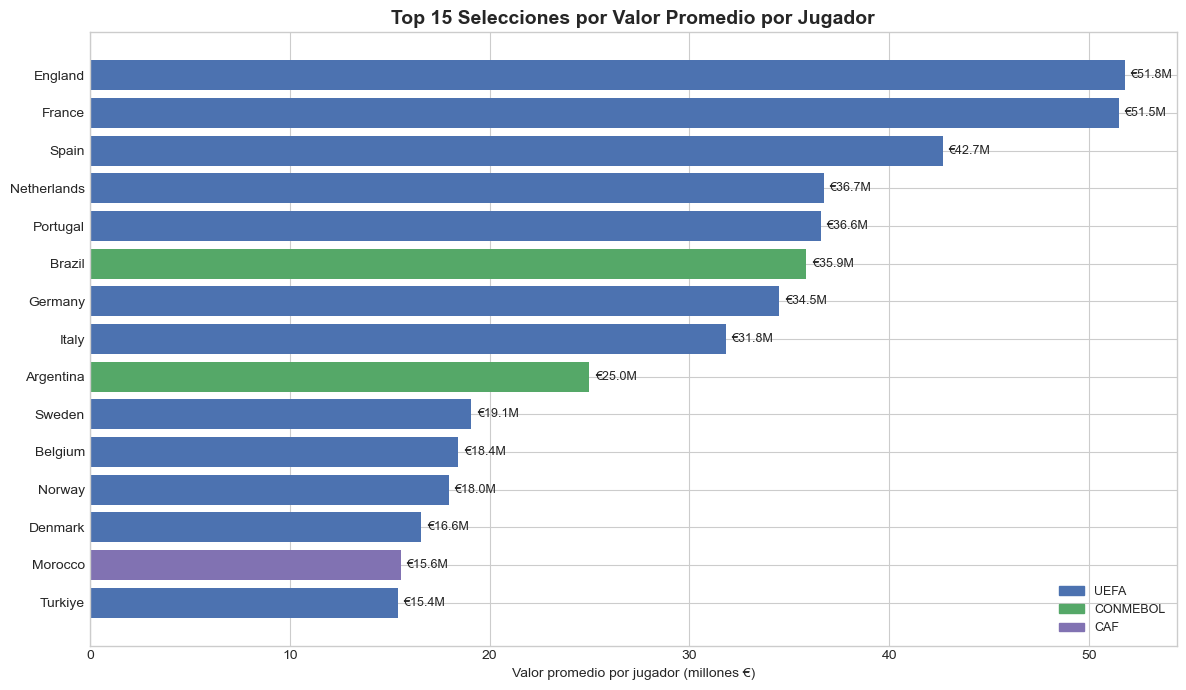

In [16]:
top15_avg = df_transfer.nlargest(15, 'avg_player_value_eur_m').sort_values('avg_player_value_eur_m')
colors2   = [CONF_PALETTE.get(c, '#888') for c in top15_avg['confederation']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_avg['country_name_tm'], top15_avg['avg_player_value_eur_m'], color=colors2)
ax.bar_label(bars, fmt='€%.1fM', padding=4, fontsize=9)
ax.set_xlabel('Valor promedio por jugador (millones €)')
ax.set_title('Top 15 Selecciones por Valor Promedio por Jugador', fontsize=14, fontweight='bold')
legend_els2 = [Patch(color=v, label=k) for k,v in CONF_PALETTE.items() if k in top15_avg['confederation'].values]
ax.legend(handles=legend_els2, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

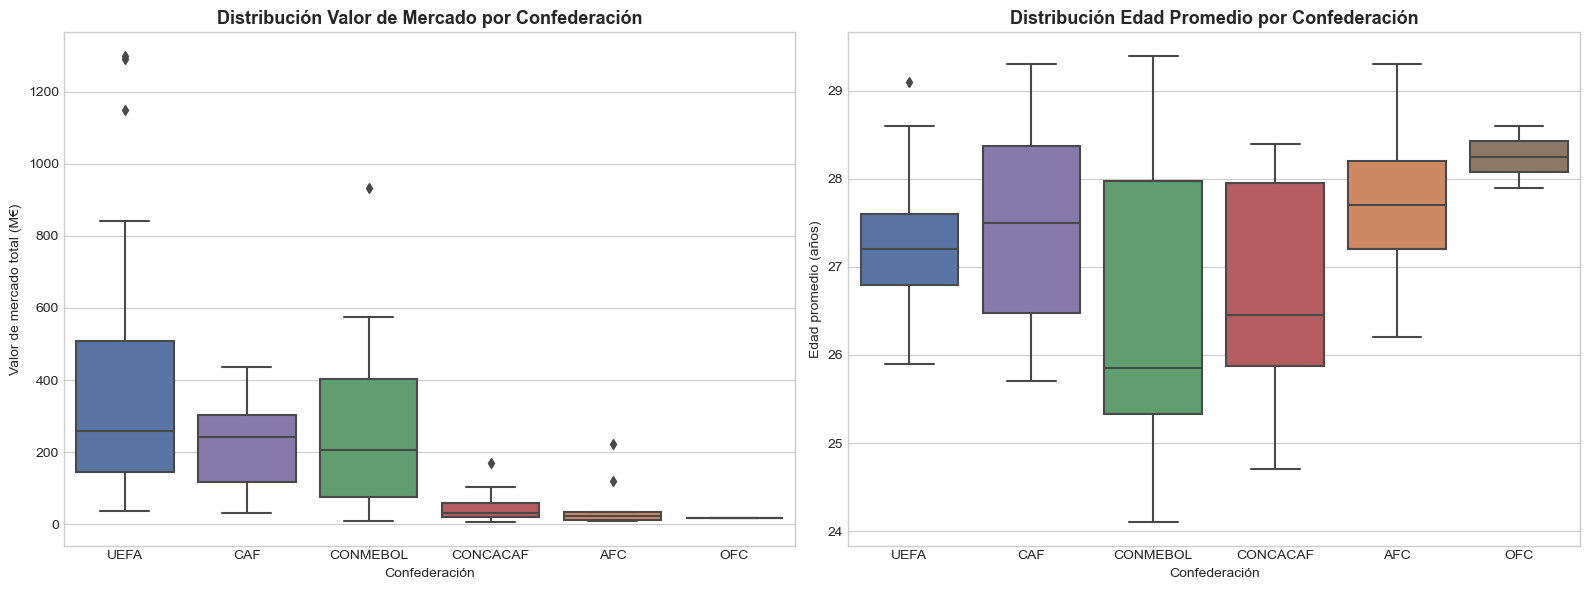

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_conf = df_transfer.groupby('confederation')['market_value_eur_m'].median().sort_values(ascending=False).index

sns.boxplot(data=df_transfer, x='confederation', y='market_value_eur_m',
            order=order_conf, palette=CONF_PALETTE, ax=axes[0])
axes[0].set_title('Distribución Valor de Mercado por Confederación', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Confederación')
axes[0].set_ylabel('Valor de mercado total (M€)')

sns.boxplot(data=df_transfer, x='confederation', y='avg_age',
            order=order_conf, palette=CONF_PALETTE, ax=axes[1])
axes[1].set_title('Distribución Edad Promedio por Confederación', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Confederación')
axes[1].set_ylabel('Edad promedio (años)')

plt.tight_layout()
plt.show()

In [18]:
fig = px.scatter(
    df_transfer,
    x='market_value_eur_m', y='avg_player_value_eur_m',
    color='confederation', text='country_code',
    color_discrete_map=CONF_PALETTE,
    title='Valor Total vs Valor Promedio por Jugador',
    labels={'market_value_eur_m': 'Valor total (M€)', 'avg_player_value_eur_m': 'Valor promedio/jugador (M€)'},
    hover_data=['country_name_tm', 'members'],
    size='members', size_max=20,
    template='plotly_white', width=900, height=550
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.show()

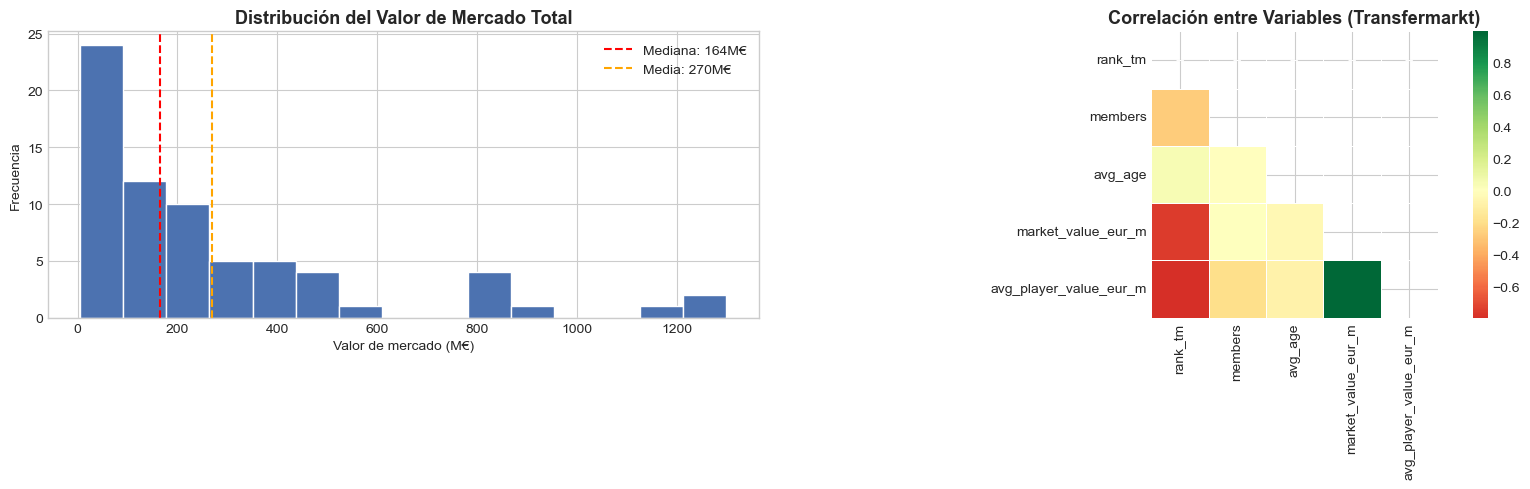

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_transfer['market_value_eur_m'], bins=15, color='#4C72B0', edgecolor='white')
axes[0].axvline(df_transfer['market_value_eur_m'].median(), color='red', linestyle='--', label=f'Mediana: {df_transfer["market_value_eur_m"].median():.0f}M€')
axes[0].axvline(df_transfer['market_value_eur_m'].mean(), color='orange', linestyle='--', label=f'Media: {df_transfer["market_value_eur_m"].mean():.0f}M€')
axes[0].set_title('Distribución del Valor de Mercado Total', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Valor de mercado (M€)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

num_cols = ['rank_tm','members','avg_age','market_value_eur_m','avg_player_value_eur_m']
corr = df_transfer[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlación entre Variables (Transfermarkt)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Observaciones (Transfermarkt):**
- El valor de mercado está fuertemente sesgado a la derecha: unas pocas selecciones UEFA concentran la mayoría del valor.
- La correlación entre valor total y valor promedio por jugador es muy alta, lo que indica que el talento individual y el conjunto van de la mano.
- UEFA domina ampliamente en valor de mercado; AFC y CONMEBOL son el segundo y tercer grupo.

## 3. EDA — Eliminatorias conjuntas

In [20]:
# Excluir anfitriones (pj=0) de estadísticas numéricas
df_elimns_activos = df_elimns[df_elimns['pj'] > 0].copy()
print(f'Equipos con partidos jugados: {len(df_elimns_activos)} / {len(df_elimns)}')
display(df_elimns_activos[['pj','g','e','p','pts','gf','gc','dg','win_pct']].describe())

Equipos con partidos jugados: 61 / 64


,pj,g,e,p,pts,gf,gc,dg,win_pct
count,61.000,61.000,61.000,61.000,61.000,61.000,61.000,61.000,61.000
mean,10.000,6.049,2.361,1.590,20.459,20.066,7.787,12.279,0.622
std,4.601,2.795,1.958,1.811,9.102,9.697,5.961,10.838,0.192
min,5.000,0.000,0.000,0.000,2.000,4.000,0.000,-18.000,0.000
25%,6.000,4.000,1.000,0.000,13.000,14.000,4.000,6.000,0.500
50%,8.000,5.000,2.000,1.000,18.000,20.000,7.000,10.000,0.625
75%,16.000,8.000,3.000,2.000,28.000,25.000,10.000,19.000,0.750
max,18.000,13.000,8.000,10.000,41.000,54.000,35.000,51.000,1.000


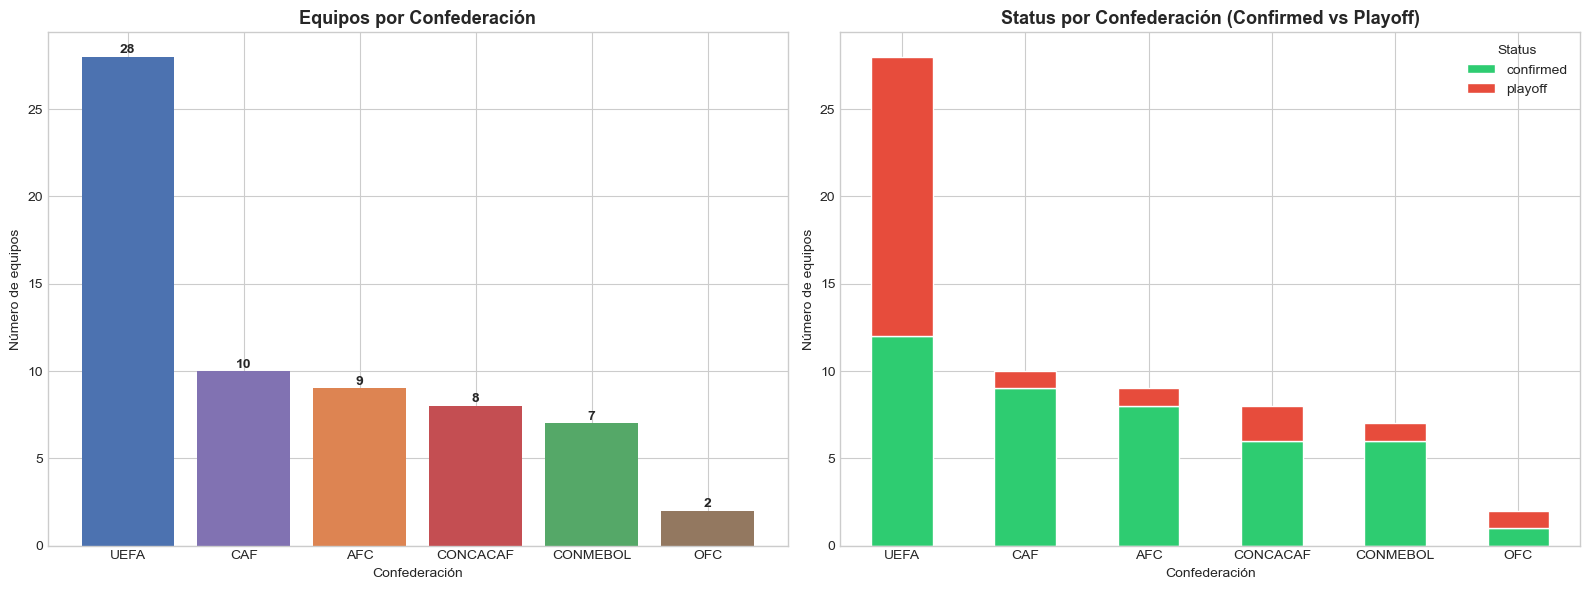

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Countplot confederaciones
conf_counts = df_elimns['confederacion'].value_counts()
axes[0].bar(conf_counts.index, conf_counts.values,
            color=[CONF_PALETTE.get(c,'#888') for c in conf_counts.index])
for i, (conf, cnt) in enumerate(zip(conf_counts.index, conf_counts.values)):
    axes[0].text(i, cnt + 0.2, str(cnt), ha='center', fontweight='bold')
axes[0].set_title('Equipos por Confederación', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Confederación')
axes[0].set_ylabel('Número de equipos')

# Stacked bar confirmed vs playoff por confederación
status_conf = df_elimns.groupby(['confederacion','status']).size().unstack(fill_value=0)
status_conf = status_conf.reindex(conf_counts.index)
status_conf.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1].set_title('Status por Confederación (Confirmed vs Playoff)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Confederación')
axes[1].set_ylabel('Número de equipos')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

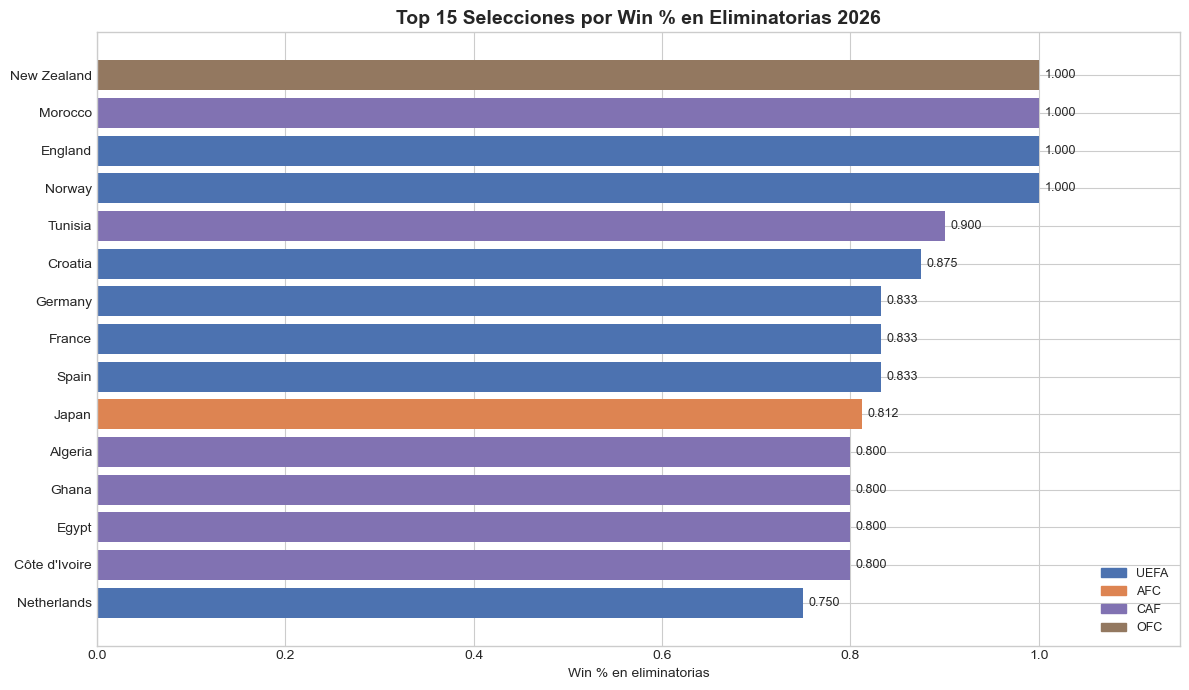

In [22]:
# Top 15 win_pct (solo activos)
top15_wp = df_elimns_activos.nlargest(15, 'win_pct').sort_values('win_pct')
colors_wp = [CONF_PALETTE.get(c,'#888') for c in top15_wp['confederacion']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_wp['nombre_completo'], top15_wp['win_pct'], color=colors_wp)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Win % en eliminatorias')
ax.set_title('Top 15 Selecciones por Win % en Eliminatorias 2026', fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
legend_els = [Patch(color=v, label=k) for k,v in CONF_PALETTE.items() if k in top15_wp['confederacion'].values]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

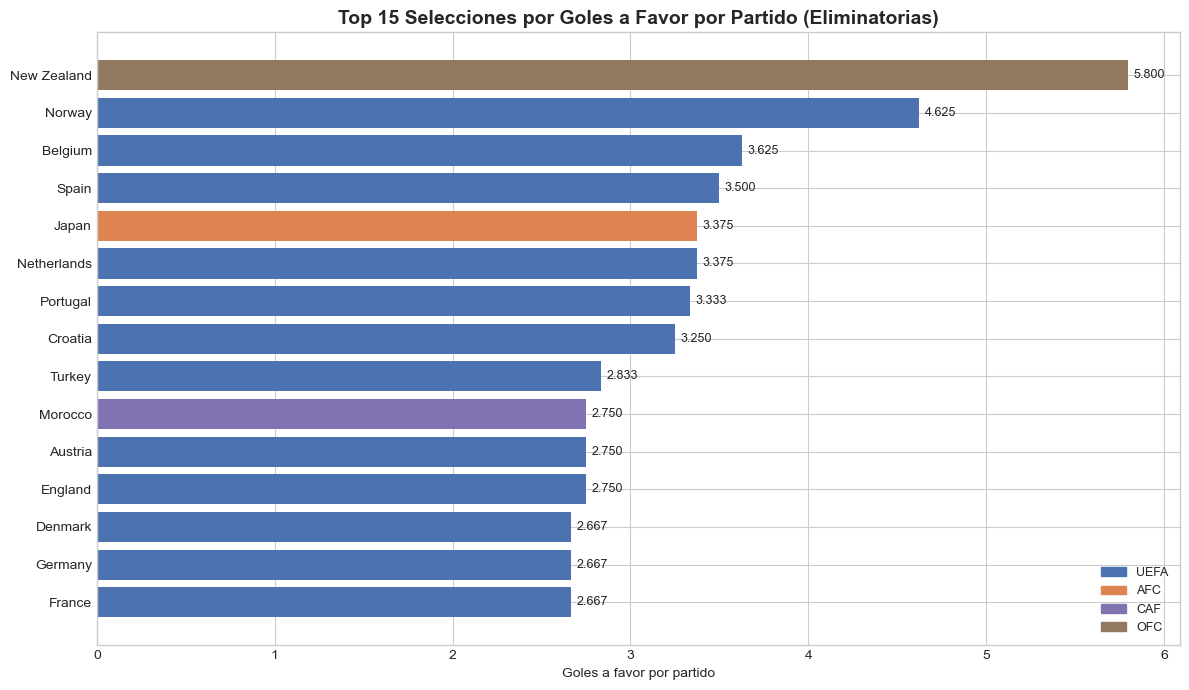

In [23]:
top15_gf = df_elimns_activos.nlargest(15, 'gf_per_game').sort_values('gf_per_game')
colors_gf = [CONF_PALETTE.get(c,'#888') for c in top15_gf['confederacion']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_gf['nombre_completo'], top15_gf['gf_per_game'], color=colors_gf)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlabel('Goles a favor por partido')
ax.set_title('Top 15 Selecciones por Goles a Favor por Partido (Eliminatorias)', fontsize=14, fontweight='bold')
legend_els = [Patch(color=v, label=k) for k,v in CONF_PALETTE.items() if k in top15_gf['confederacion'].values]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
fig = px.scatter(
    df_elimns_activos,
    x='gf_per_game', y='gc_per_game',
    color='confederacion', text='country_code',
    color_discrete_map=CONF_PALETTE,
    title='Ataque vs Defensa en Eliminatorias (goles por partido)',
    labels={'gf_per_game': 'Goles a favor / partido', 'gc_per_game': 'Goles en contra / partido'},
    hover_data=['nombre_completo','win_pct','pj'],
    template='plotly_white', width=900, height=580
)
fig.update_traces(textposition='top center', textfont_size=9)
# Cuadrantes: mejor arriba-izquierda (mucho ataque, poca defensa recibida)
gf_med = df_elimns_activos['gf_per_game'].median()
gc_med = df_elimns_activos['gc_per_game'].median()
fig.add_hline(y=gc_med, line_dash='dash', line_color='gray', opacity=0.5, annotation_text='Mediana GC/P')
fig.add_vline(x=gf_med, line_dash='dash', line_color='gray', opacity=0.5, annotation_text='Mediana GF/P')
fig.show()

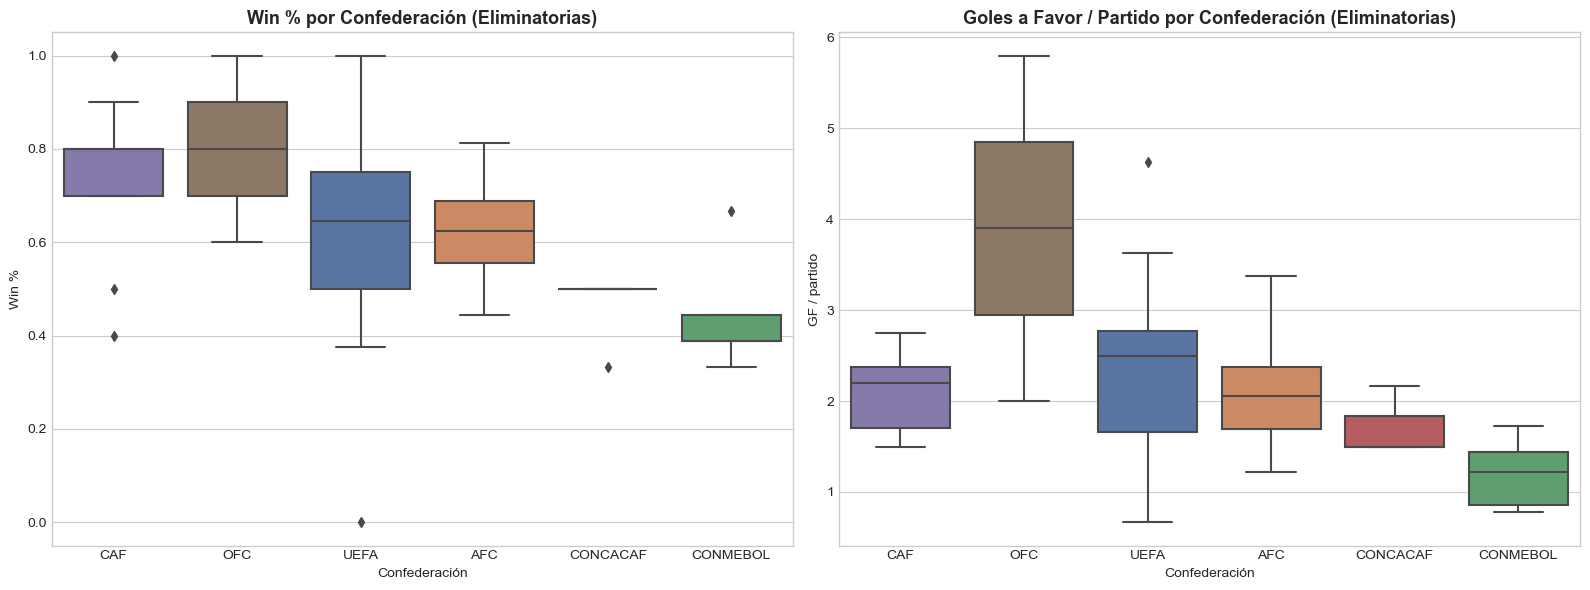

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_conf_e = df_elimns_activos.groupby('confederacion')['win_pct'].median().sort_values(ascending=False).index

sns.boxplot(data=df_elimns_activos, x='confederacion', y='win_pct',
            order=order_conf_e, palette=CONF_PALETTE, ax=axes[0])
axes[0].set_title('Win % por Confederación (Eliminatorias)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Confederación')
axes[0].set_ylabel('Win %')

sns.boxplot(data=df_elimns_activos, x='confederacion', y='gf_per_game',
            order=order_conf_e, palette=CONF_PALETTE, ax=axes[1])
axes[1].set_title('Goles a Favor / Partido por Confederación (Eliminatorias)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Confederación')
axes[1].set_ylabel('GF / partido')

plt.tight_layout()
plt.show()

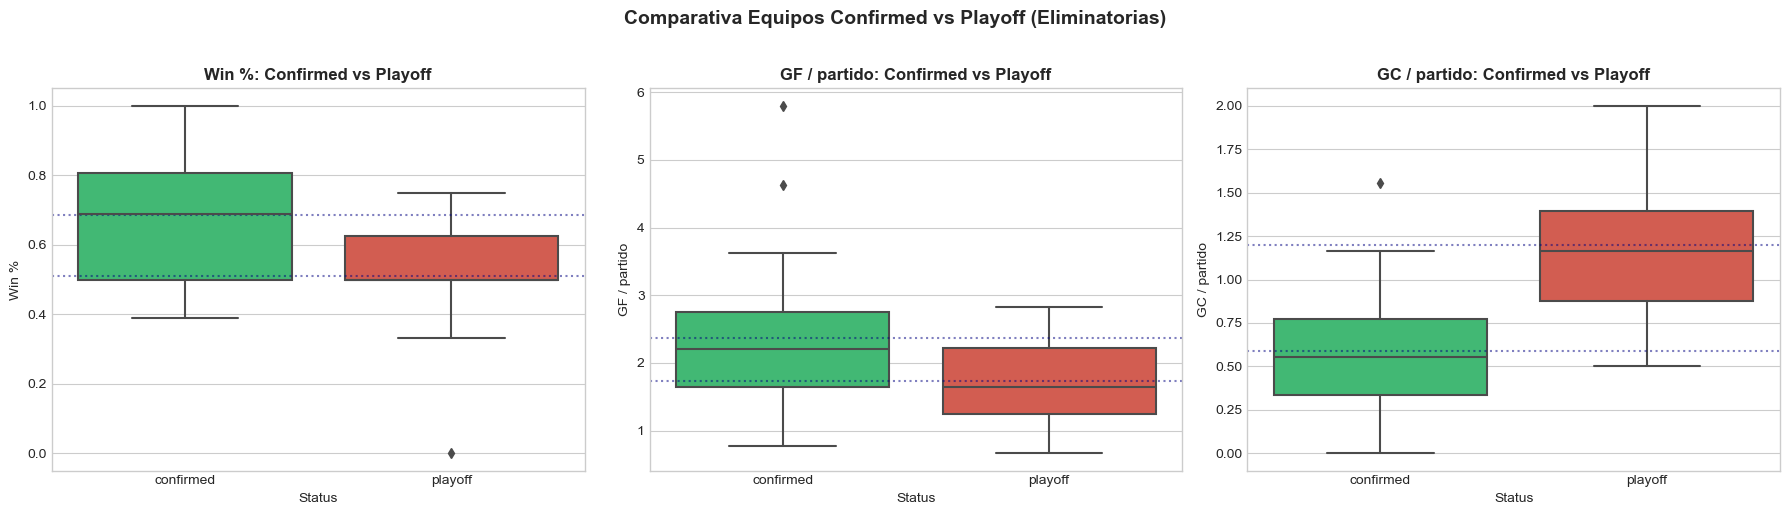


Medianas por status:


,win_pct,gf_per_game,gc_per_game
status,,,
confirmed,0.688,2.200,0.556
playoff,0.500,1.646,1.167


In [26]:
metrics = ['win_pct', 'gf_per_game', 'gc_per_game']
labels  = ['Win %', 'GF / partido', 'GC / partido']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, lbl in zip(axes, metrics, labels):
    sns.boxplot(data=df_elimns_activos, x='status', y=col,
                palette={'confirmed':'#2ecc71','playoff':'#e74c3c'}, ax=ax)
    ax.set_title(f'{lbl}: Confirmed vs Playoff', fontsize=12, fontweight='bold')
    ax.set_xlabel('Status')
    ax.set_ylabel(lbl)
    # Medias
    for status, grp in df_elimns_activos.groupby('status'):
        med = grp[col].mean()
        x_pos = 0 if status == 'confirmed' else 1
        ax.axhline(med, color='navy', linestyle=':', alpha=0.5)

plt.suptitle('Comparativa Equipos Confirmed vs Playoff (Eliminatorias)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nMedianas por status:')
display(df_elimns_activos.groupby('status')[metrics].median().round(3))

**Observaciones (Eliminatorias):**
- UEFA aporta la mayor cantidad de equipos (28), seguida de AFC (9) y CAF (10).
- Los equipos *confirmed* tienen sistemáticamente mayor win% y mejor ataque que los *playoff*.
- OFC y CONMEBOL tienen los equipos más goleadores por partido; el cuadrante ideal (mucho ataque, poca defensa recibida) está dominado por selecciones UEFA.
- NOR, ENG, JPN tienen win%=1.0, habiendo ganado todos sus partidos de fase de grupos.

## 4. EDA — Ranking FIFA histórico

In [27]:
print('Rango de años:', df_ranking['year'].min(), '–', df_ranking['year'].max())
print('Equipos únicos:', df_ranking['country_code'].nunique())
display(df_ranking['ranking'].describe())

Rango de años: 1993 – 2026
Equipos únicos: 64


count   2107.000
mean      46.222
std       36.725
min        1.000
25%       17.000
50%       37.000
75%       66.500
max      191.000
Name: ranking, dtype: float64

In [28]:
# Top 10 selecciones con mejor ranking promedio (menor valor = mejor)
df_rank_2026 = df_ranking[df_ranking['year'] == 2026].set_index('country_code')['ranking']
top10_codes  = df_rank_2026.nsmallest(10).index.tolist()

df_top10 = df_ranking[df_ranking['country_code'].isin(top10_codes)]

fig = px.line(
    df_top10, x='year', y='ranking', color='country_code',
    title='Evolución del Ranking FIFA — Top 10 Selecciones (2026)',
    labels={'year': 'Año', 'ranking': 'Ranking FIFA', 'country_code': 'Selección'},
    template='plotly_white', width=1000, height=550
)
fig.update_yaxes(autorange='reversed', title='Ranking FIFA (1 = mejor)')
fig.update_xaxes(title='Año')
fig.show()

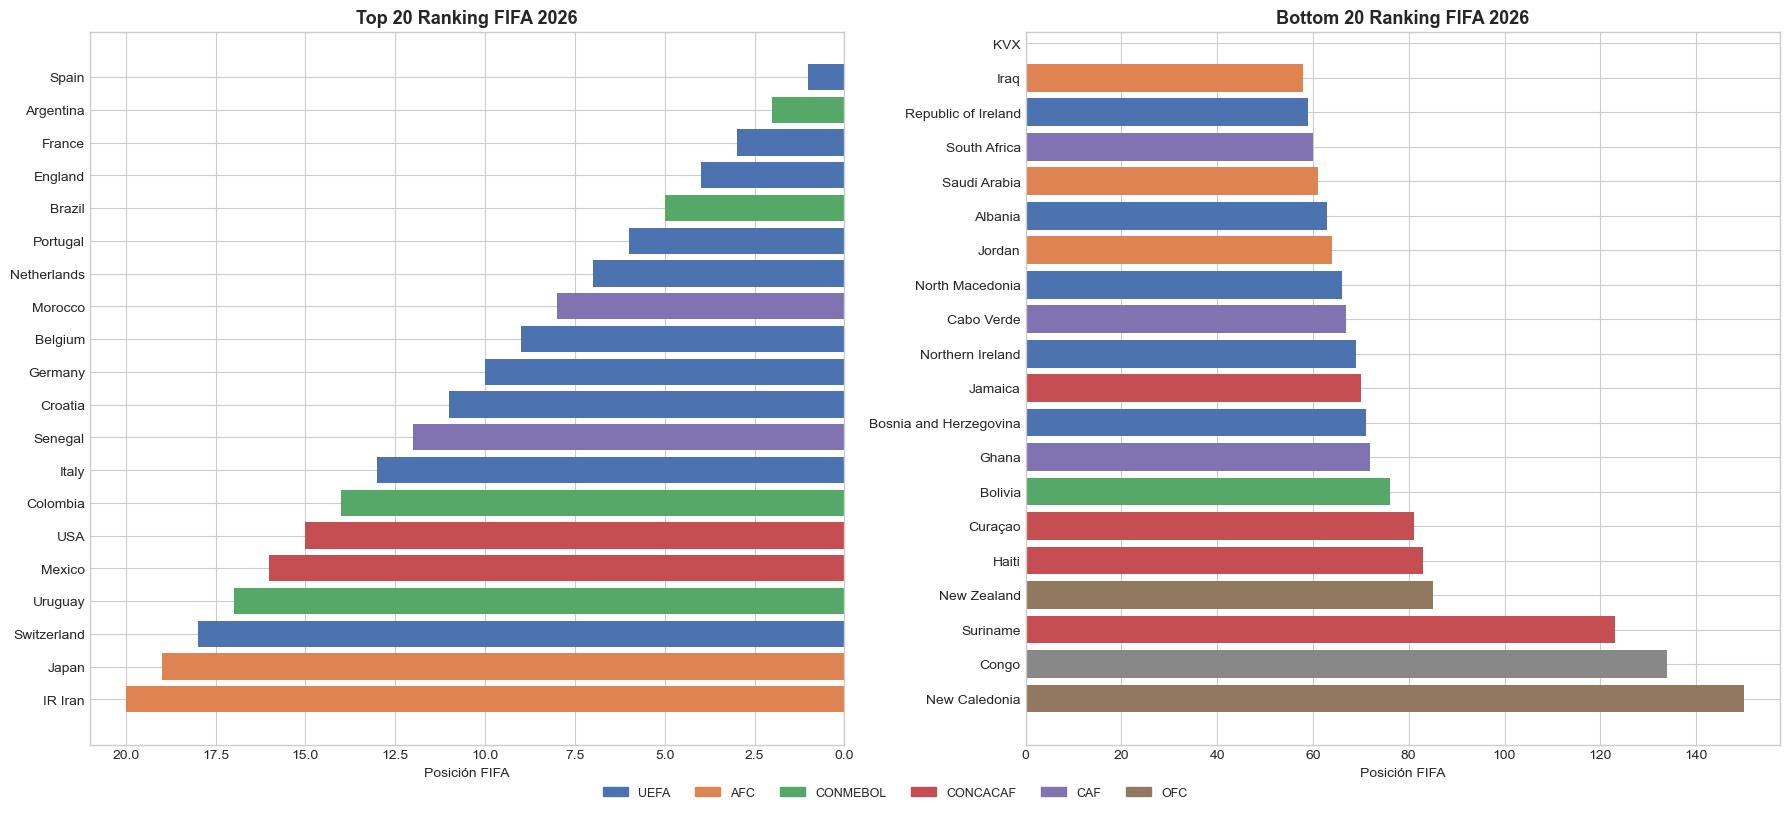

In [29]:
df_r26 = df_ranking[df_ranking['year'] == 2026].sort_values('ranking').reset_index(drop=True)
df_r26 = df_r26.merge(df_elimns[['country_code','confederacion']], on='country_code', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20
top20 = df_r26.head(20)
colors_t20 = [CONF_PALETTE.get(c,'#888') for c in top20['confederacion']]
axes[0].barh(top20['team_name'][::-1], top20['ranking'][::-1], color=colors_t20[::-1])
axes[0].set_title('Top 20 Ranking FIFA 2026', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Posición FIFA')
axes[0].invert_xaxis()

# Bottom 20
bot20 = df_r26.tail(20).sort_values('ranking', ascending=False)
colors_b20 = [CONF_PALETTE.get(c,'#888') for c in bot20['confederacion']]
axes[1].barh(bot20['team_name'], bot20['ranking'], color=colors_b20)
axes[1].set_title('Bottom 20 Ranking FIFA 2026', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Posición FIFA')

from matplotlib.patches import Patch
legend_els = [Patch(color=v, label=k) for k,v in CONF_PALETTE.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

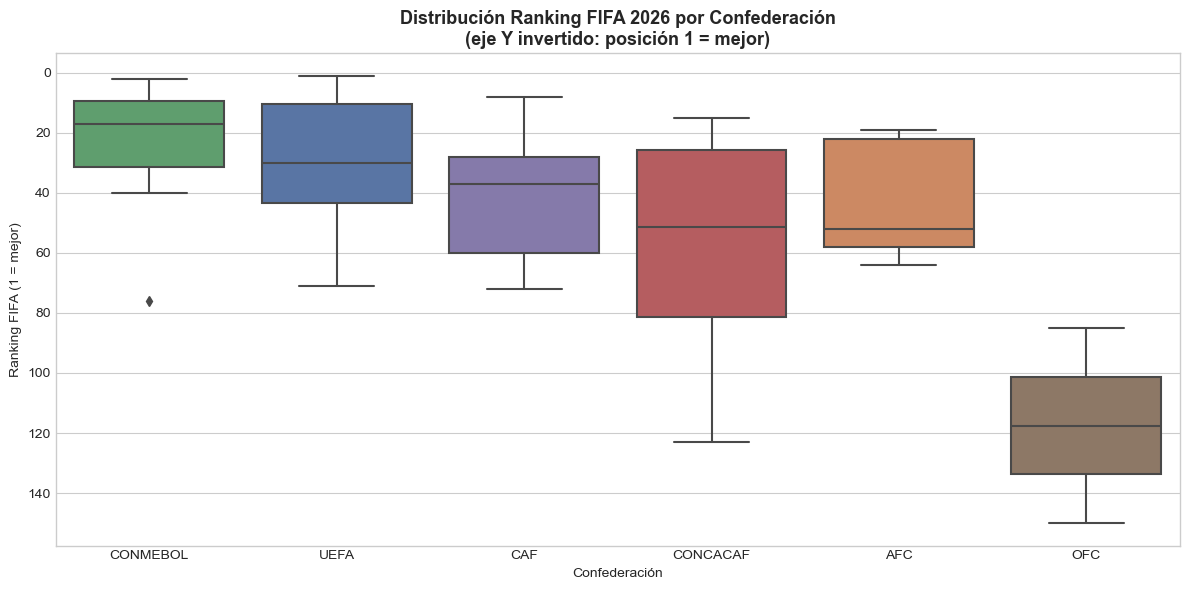

In [30]:
df_r26_box = df_r26.dropna(subset=['confederacion'])
order_rk   = df_r26_box.groupby('confederacion')['ranking'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_r26_box, x='confederacion', y='ranking', order=order_rk,
            palette=CONF_PALETTE, ax=ax)
ax.invert_yaxis()
ax.set_title('Distribución Ranking FIFA 2026 por Confederación\n(eje Y invertido: posición 1 = mejor)', fontsize=13, fontweight='bold')
ax.set_xlabel('Confederación')
ax.set_ylabel('Ranking FIFA (1 = mejor)')
plt.tight_layout()
plt.show()

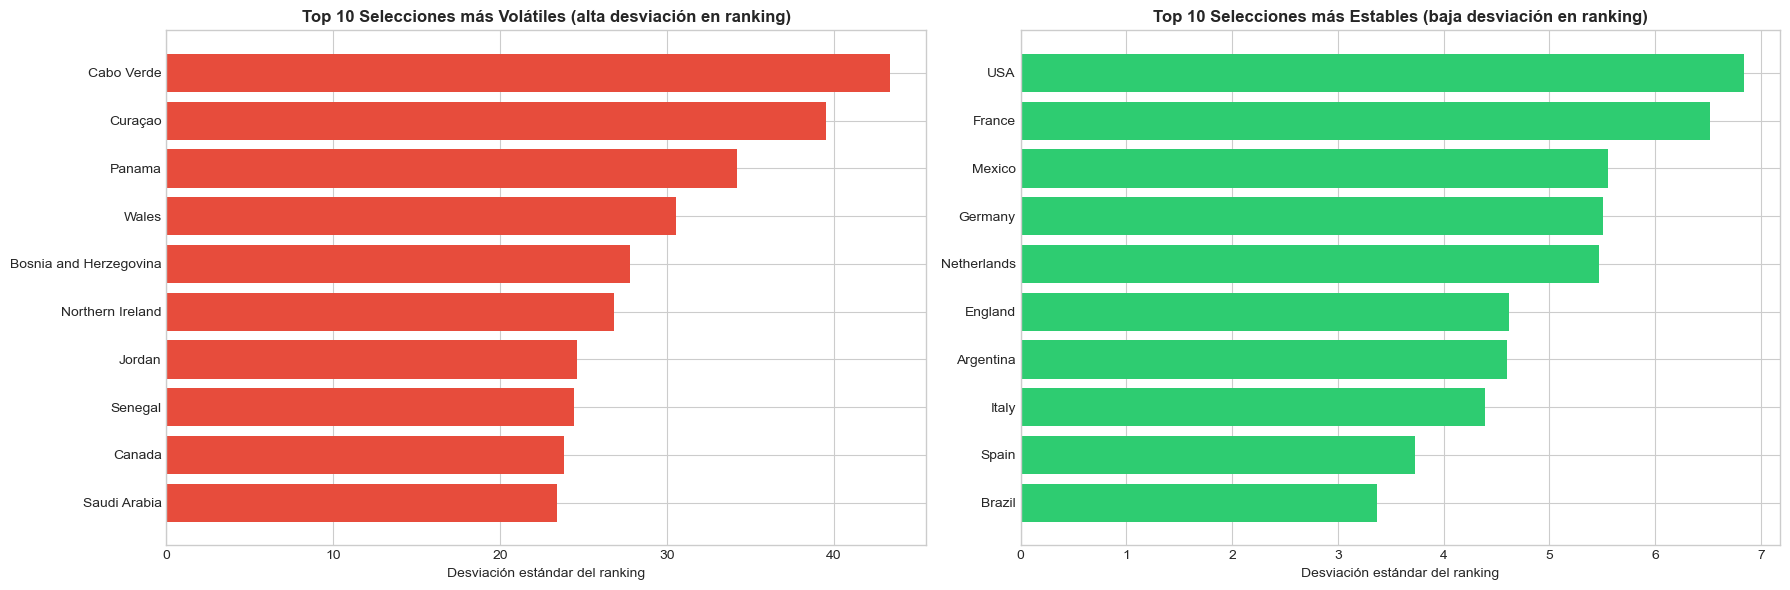

In [31]:
rank_vol = df_ranking.groupby('country_code')['ranking'].std().sort_values(ascending=False)
rank_vol = rank_vol.reset_index().rename(columns={'ranking':'std_ranking'})
rank_vol = rank_vol.merge(df_ranking[['country_code','team_name']].drop_duplicates(), on='country_code', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top10_vol = rank_vol.head(10).sort_values('std_ranking')
axes[0].barh(top10_vol['team_name'], top10_vol['std_ranking'], color='#e74c3c')
axes[0].set_title('Top 10 Selecciones más Volátiles (alta desviación en ranking)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Desviación estándar del ranking')

bot10_vol = rank_vol[rank_vol['std_ranking'] > 0].tail(10).sort_values('std_ranking')
axes[1].barh(bot10_vol['team_name'], bot10_vol['std_ranking'], color='#2ecc71')
axes[1].set_title('Top 10 Selecciones más Estables (baja desviación en ranking)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Desviación estándar del ranking')

plt.tight_layout()
plt.show()

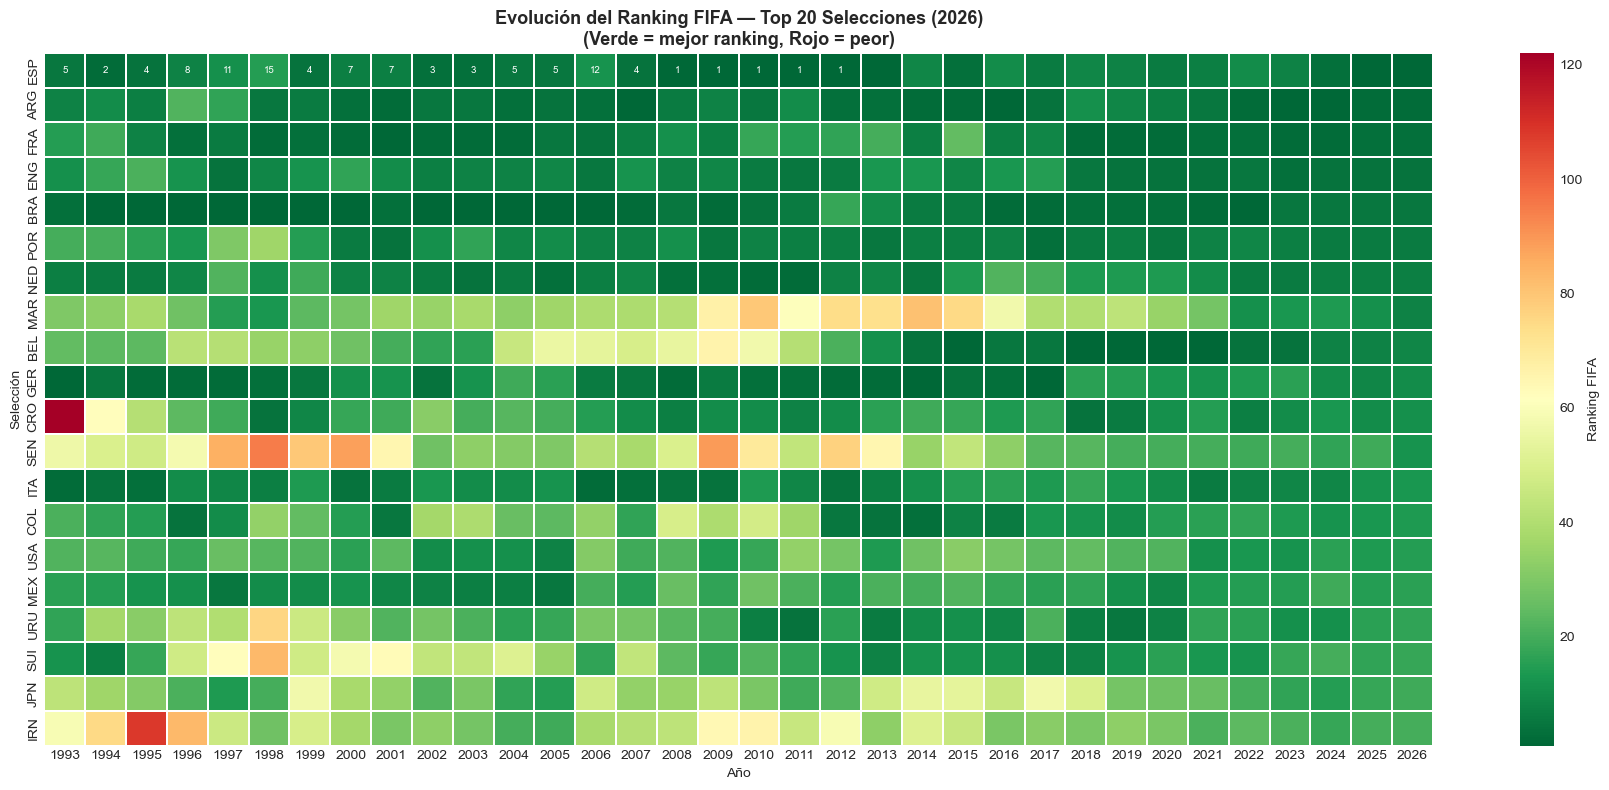

In [32]:
top20_codes = df_rank_2026.nsmallest(20).index.tolist()
df_heat = df_ranking[df_ranking['country_code'].isin(top20_codes)].pivot_table(
    index='country_code', columns='year', values='ranking')

# Ordenar por ranking 2026
df_heat = df_heat.loc[df_rank_2026.nsmallest(20).index.intersection(df_heat.index)]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(df_heat, cmap='RdYlGn_r', annot=True, fmt='.0f', linewidths=0.3,
            annot_kws={'size': 7}, ax=ax, cbar_kws={'label': 'Ranking FIFA'})
ax.set_title('Evolución del Ranking FIFA — Top 20 Selecciones (2026)\n(Verde = mejor ranking, Rojo = peor)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Selección')
plt.tight_layout()
plt.show()

**Observaciones (Ranking FIFA):**
- UEFA domina el top del ranking 2026; las confederaciones con peores posiciones son CONCACAF y OFC.
- Las selecciones más volátiles suelen ser las que han ascendido o descendido abruptamente (ej. selecciones que emergieron recientemente).
- Brasil, Argentina y Francia se han mantenido consistentemente entre los 10 primeros a lo largo de los años.

## 5. EDA — Historial Mundialista (1930–2022)

In [33]:
df_hist_activos = df_historial[df_historial['pj'] > 0].copy()
df_hist_cero    = df_historial[df_historial['pj'] == 0].copy()
print(f'Con historial mundialista : {len(df_hist_activos)} selecciones')
print(f'Sin historial mundialista : {len(df_hist_cero)} selecciones')
display(df_hist_activos[['pj','g','win_pct','gf','gc','gf_per_game','gc_per_game']].describe())

Con historial mundialista : 55 selecciones
Sin historial mundialista : 9 selecciones


,pj,g,win_pct,gf,gc,gf_per_game,gc_per_game
count,55.000,55.000,55.000,55.000,55.000,55.000,55.000
mean,29.145,12.018,0.298,42.164,39.036,1.160,1.623
std,27.706,16.539,0.173,53.041,30.856,0.444,0.698
min,3.000,0.000,0.000,1.000,4.000,0.167,0.769
25%,8.500,2.000,0.192,8.500,14.000,0.860,1.212
50%,21.000,5.000,0.333,20.000,30.000,1.111,1.444
75%,38.000,15.500,0.415,52.000,59.000,1.438,1.773
max,114.000,76.000,0.667,237.000,130.000,2.079,4.667


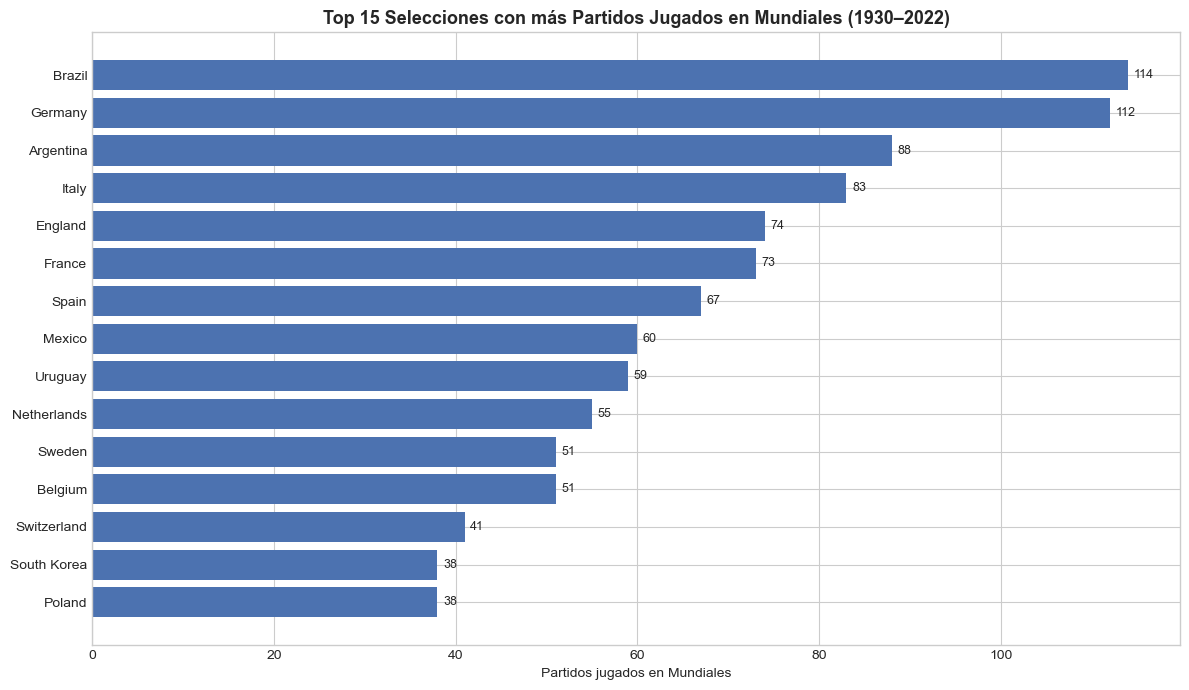

In [34]:
top15_pj = df_hist_activos.nlargest(15, 'pj').sort_values('pj')
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_pj['nombre_completo'], top15_pj['pj'], color='#4C72B0')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Partidos jugados en Mundiales')
ax.set_title('Top 15 Selecciones con más Partidos Jugados en Mundiales (1930–2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

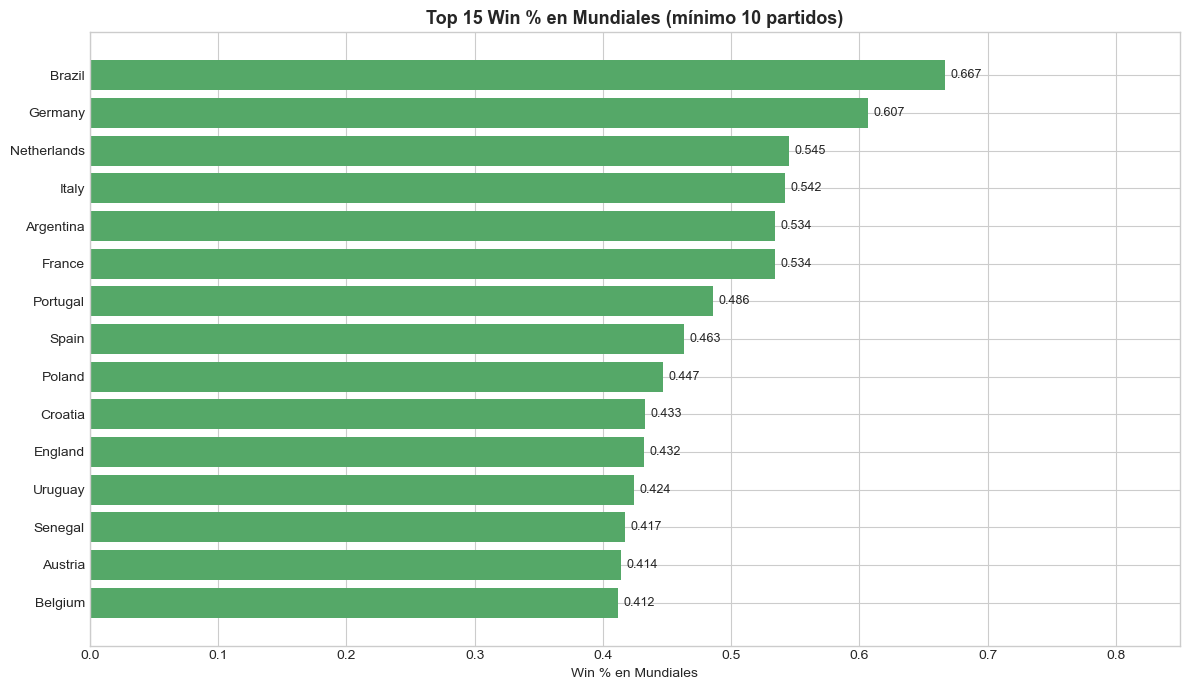

In [35]:
# Filtrar >10 partidos para evitar sesgos
df_hist_10 = df_hist_activos[df_hist_activos['pj'] > 10]
top15_hw   = df_hist_10.nlargest(15, 'win_pct').sort_values('win_pct')

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_hw['nombre_completo'], top15_hw['win_pct'], color='#55A868')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlim(0, 0.85)
ax.set_xlabel('Win % en Mundiales')
ax.set_title('Top 15 Win % en Mundiales (mínimo 10 partidos)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

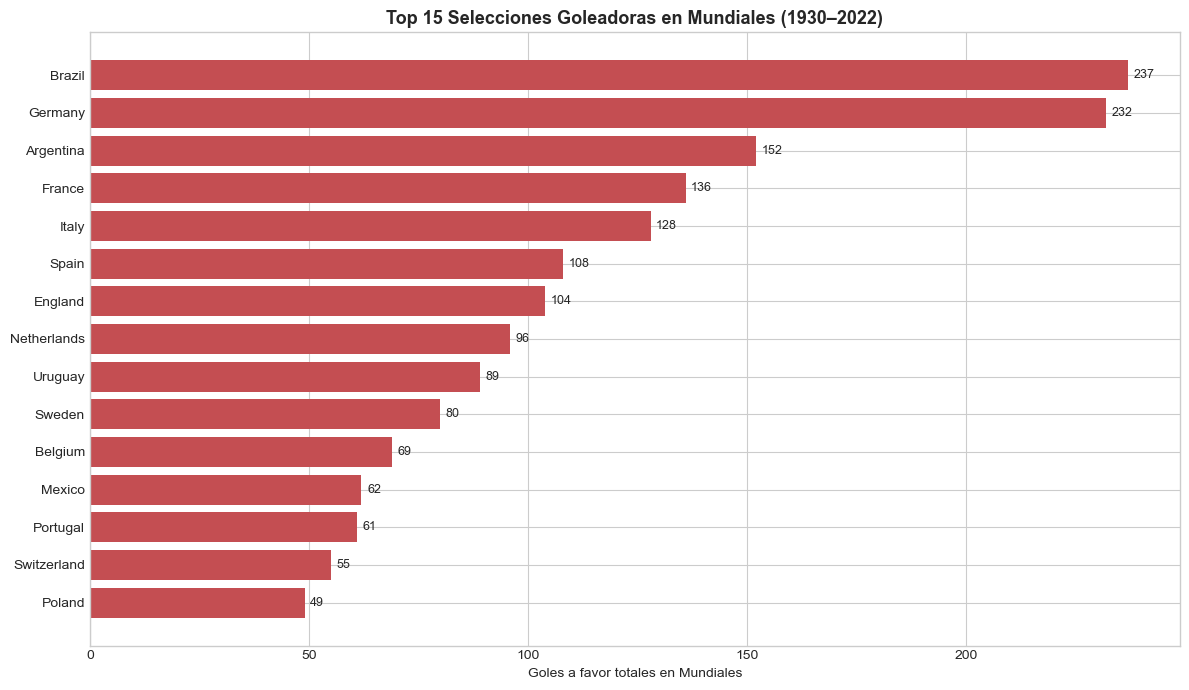

In [36]:
top15_gf_hist = df_hist_activos.nlargest(15, 'gf').sort_values('gf')

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_gf_hist['nombre_completo'], top15_gf_hist['gf'], color='#C44E52')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Goles a favor totales en Mundiales')
ax.set_title('Top 15 Selecciones Goleadoras en Mundiales (1930–2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
df_hist_m = df_hist_activos.merge(df_elimns[['country_code','confederacion']], on='country_code', how='left')

fig = px.scatter(
    df_hist_m,
    x='pj', y='win_pct',
    color='confederacion', text='country_code',
    color_discrete_map=CONF_PALETTE,
    title='Experiencia vs Rendimiento en Mundiales (Partidos jugados vs Win %)',
    labels={'pj': 'Partidos jugados', 'win_pct': 'Win %'},
    hover_data=['nombre_completo','gf','gc','status'],
    size='gf', size_max=25,
    template='plotly_white', width=900, height=580
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.show()


Medianas win% por status (equipos con historial):


,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
confirmed,38.000,0.296,0.182,0.000,0.188,0.282,0.422,0.667
playoff,17.000,0.301,0.157,0.000,0.231,0.333,0.391,0.542


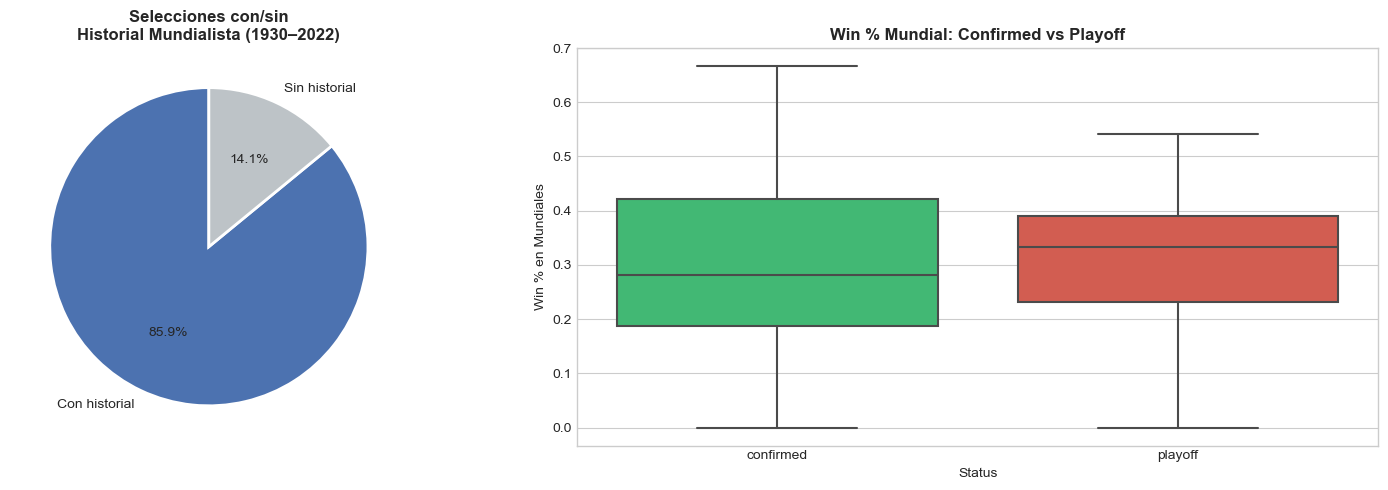

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución con/sin historial
hist_counts = pd.Series({'Con historial': len(df_hist_activos), 'Sin historial': len(df_hist_cero)})
axes[0].pie(hist_counts, labels=hist_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#bdc3c7'], startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Selecciones con/sin\nHistorial Mundialista (1930–2022)', fontsize=12, fontweight='bold')

# Comparativa confirmed vs playoff por win_pct mundialista
sns.boxplot(data=df_hist_activos, x='status', y='win_pct',
            palette={'confirmed':'#2ecc71','playoff':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Win % Mundial: Confirmed vs Playoff', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Win % en Mundiales')

print('\nMedianas win% por status (equipos con historial):')
display(df_hist_activos.groupby('status')['win_pct'].describe().round(3))

plt.tight_layout()
plt.show()

**Observaciones (Historial Mundialista):**
- Brasil y Alemania dominan en partidos jugados y victorias absolutas, siendo los equipos más experimentados del torneo.
- El 14% de las 64 selecciones nunca ha disputado un Mundial (Albania, Kosovo, Curaçao, etc.).
- Los equipos *confirmed* para 2026 tienen sistemáticamente mayor win% histórico que los de *playoff*, lo que sugiere que la clasificación directa se correlaciona con tradición mundialista.
- La relación entre partidos jugados y win% no es lineal: algunos equipos con poca experiencia tienen altos porcentajes.

## 6. Análisis cruzado (merge de datasets)

In [39]:
# Ranking 2026 por país
rk_2026 = df_ranking[df_ranking['year'] == 2026][['country_code','ranking']].rename(columns={'ranking':'ranking_2026'})

# Dataset unificado
df_unified = (
    df_elimns
    .rename(columns={'win_pct':'win_pct_elim', 'gf_per_game':'gf_per_game_elim',
                     'gc_per_game':'gc_per_game_elim', 'pj':'pj_elim'})
    .merge(rk_2026, on='country_code', how='left')
    .merge(
        df_historial[['country_code','win_pct','gf_per_game','pj']]
            .rename(columns={'win_pct':'win_pct_hist','gf_per_game':'gf_per_game_hist','pj':'pj_hist'}),
        on='country_code', how='left'
    )
    .merge(
        df_transfer[['country_code','market_value_eur_m','avg_player_value_eur_m','avg_age']],
        on='country_code', how='left'
    )
)
print(f'Dataset unificado: {df_unified.shape}')
display(df_unified.head(3))

Dataset unificado: (64, 22)


,country_code,nombre_completo,confederacion,status,pj_elim,g,e,p,pts,gf,...,gf_per_game_elim,gc_per_game_elim,win_pct_elim,ranking_2026,win_pct_hist,gf_per_game_hist,pj_hist,market_value_eur_m,avg_player_value_eur_m,avg_age
0,NOR,Norway,UEFA,confirmed,8,8,0,0,24,37,...,4.625,0.625,1.000,32.000,0.250,0.875,8,502.900,17.960,26.100
1,ENG,England,UEFA,confirmed,8,8,0,0,24,22,...,2.750,0.000,1.000,4.000,0.432,1.405,74,1300.000,51.800,26.900
2,CRO,Croatia,UEFA,confirmed,8,7,1,0,22,26,...,3.250,0.500,0.875,11.000,0.433,1.433,30,258.500,11.240,28.600


In [40]:
df_u = df_unified.dropna(subset=['market_value_eur_m','ranking_2026'])

fig = px.scatter(
    df_u,
    x='market_value_eur_m', y='ranking_2026',
    color='confederacion', text='country_code',
    color_discrete_map=CONF_PALETTE,
    title='Valor de Mercado vs Ranking FIFA 2026',
    labels={'market_value_eur_m': 'Valor de mercado (M€)', 'ranking_2026': 'Ranking FIFA 2026'},
    hover_data=['nombre_completo','status'],
    template='plotly_white', width=900, height=560
)
fig.update_yaxes(autorange='reversed', title='Ranking FIFA 2026 (1 = mejor)')
fig.update_traces(textposition='top center', textfont_size=9)
# Correlación
r = df_u[['market_value_eur_m','ranking_2026']].corr().iloc[0,1]
fig.add_annotation(x=0.05, y=0.95, xref='paper', yref='paper',
                   text=f'Correlación r = {r:.3f}', showarrow=False,
                   bgcolor='white', bordercolor='gray')
fig.show()

In [41]:
df_u2 = df_unified.dropna(subset=['market_value_eur_m','win_pct_elim'])
df_u2 = df_u2[df_u2['pj_elim'] > 0]

fig = px.scatter(
    df_u2,
    x='market_value_eur_m', y='win_pct_elim',
    color='confederacion', text='country_code',
    color_discrete_map=CONF_PALETTE,
    title='Valor de Mercado vs Win % Eliminatorias',
    labels={'market_value_eur_m': 'Valor de mercado (M€)', 'win_pct_elim': 'Win % eliminatorias'},
    hover_data=['nombre_completo','status'],
    template='plotly_white', width=900, height=560
)
fig.update_traces(textposition='top center', textfont_size=9)
r2 = df_u2[['market_value_eur_m','win_pct_elim']].corr().iloc[0,1]
fig.add_annotation(x=0.05, y=0.95, xref='paper', yref='paper',
                   text=f'Correlación r = {r2:.3f}', showarrow=False,
                   bgcolor='white', bordercolor='gray')
fig.show()

In [42]:
df_u3 = df_unified.dropna(subset=['ranking_2026','win_pct_elim'])
df_u3 = df_u3[df_u3['pj_elim'] > 0]

fig = px.scatter(
    df_u3,
    x='ranking_2026', y='win_pct_elim',
    color='confederacion', text='country_code',
    color_discrete_map=CONF_PALETTE,
    title='Ranking FIFA 2026 vs Win % Eliminatorias',
    labels={'ranking_2026': 'Ranking FIFA 2026', 'win_pct_elim': 'Win % eliminatorias'},
    hover_data=['nombre_completo','status'],
    template='plotly_white', width=900, height=560
)
fig.update_xaxes(autorange='reversed', title='Ranking FIFA 2026 (izquierda = mejor)')
fig.update_traces(textposition='top center', textfont_size=9)
r3 = df_u3[['ranking_2026','win_pct_elim']].corr().iloc[0,1]
fig.add_annotation(x=0.05, y=0.95, xref='paper', yref='paper',
                   text=f'Correlación r = {r3:.3f}', showarrow=False,
                   bgcolor='white', bordercolor='gray')
fig.show()

In [43]:
df_u4 = df_unified.dropna(subset=['win_pct_hist','win_pct_elim'])
df_u4 = df_u4[(df_u4['pj_elim'] > 0) & (df_u4['pj_hist'] > 0)]

fig = px.scatter(
    df_u4,
    x='win_pct_hist', y='win_pct_elim',
    color='confederacion', text='country_code',
    color_discrete_map=CONF_PALETTE,
    title='Win % Histórico en Mundiales vs Win % Eliminatorias 2026',
    labels={'win_pct_hist': 'Win % en Mundiales (1930–2022)', 'win_pct_elim': 'Win % Eliminatorias 2026'},
    hover_data=['nombre_completo','status','pj_hist'],
    template='plotly_white', width=900, height=560
)
fig.update_traces(textposition='top center', textfont_size=9)
r4 = df_u4[['win_pct_hist','win_pct_elim']].corr().iloc[0,1]
fig.add_annotation(x=0.05, y=0.95, xref='paper', yref='paper',
                   text=f'Correlación r = {r4:.3f}', showarrow=False,
                   bgcolor='white', bordercolor='gray')
fig.show()

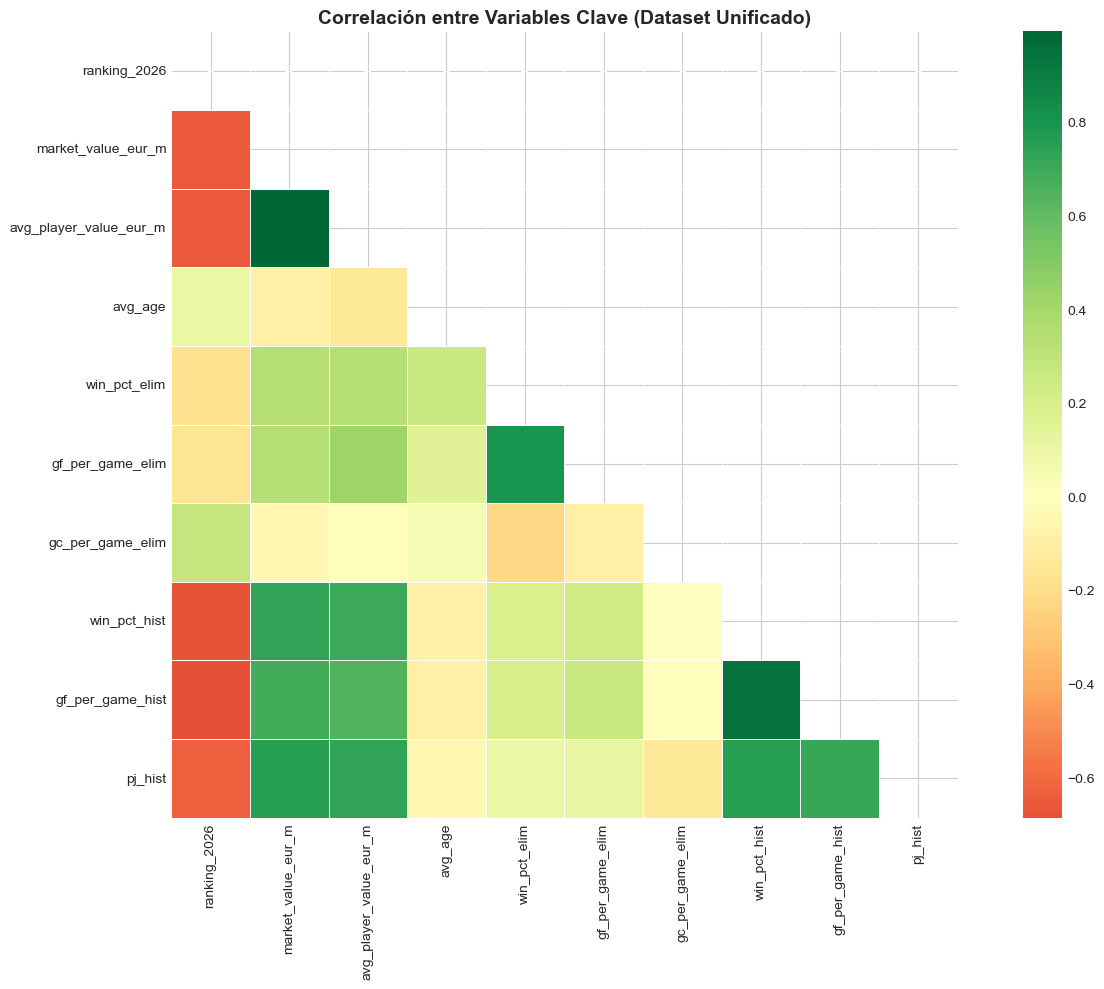

In [44]:
key_vars = ['ranking_2026','market_value_eur_m','avg_player_value_eur_m','avg_age',
            'win_pct_elim','gf_per_game_elim','gc_per_game_elim',
            'win_pct_hist','gf_per_game_hist','pj_hist']

corr_matrix = df_unified[key_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Correlación entre Variables Clave (Dataset Unificado)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

,nombre_completo,confederacion,composite_score,norm_ranking_2026,norm_market_value_eur_m,norm_win_pct_elim,norm_win_pct_hist,norm_gf_per_game_elim
1,England,UEFA,0.820,0.980,1.000,1.000,0.648,0.474
7,France,UEFA,0.814,0.987,0.992,0.833,0.801,0.460
6,Spain,UEFA,0.803,1.000,0.884,0.833,0.694,0.603
8,Germany,UEFA,0.756,0.940,0.635,0.833,0.910,0.460
3,Netherlands,UEFA,0.746,0.960,0.620,0.750,0.817,0.582
11,Portugal,UEFA,0.716,0.966,0.645,0.667,0.729,0.575
12,Italy,UEFA,0.714,0.919,0.635,0.750,0.813,0.453
41,Brazil,CONMEBOL,0.673,0.973,0.716,0.444,1.000,0.230
0,Norway,UEFA,0.670,0.792,0.384,1.000,0.375,0.797
2,Croatia,UEFA,0.643,0.933,0.196,0.875,0.649,0.560


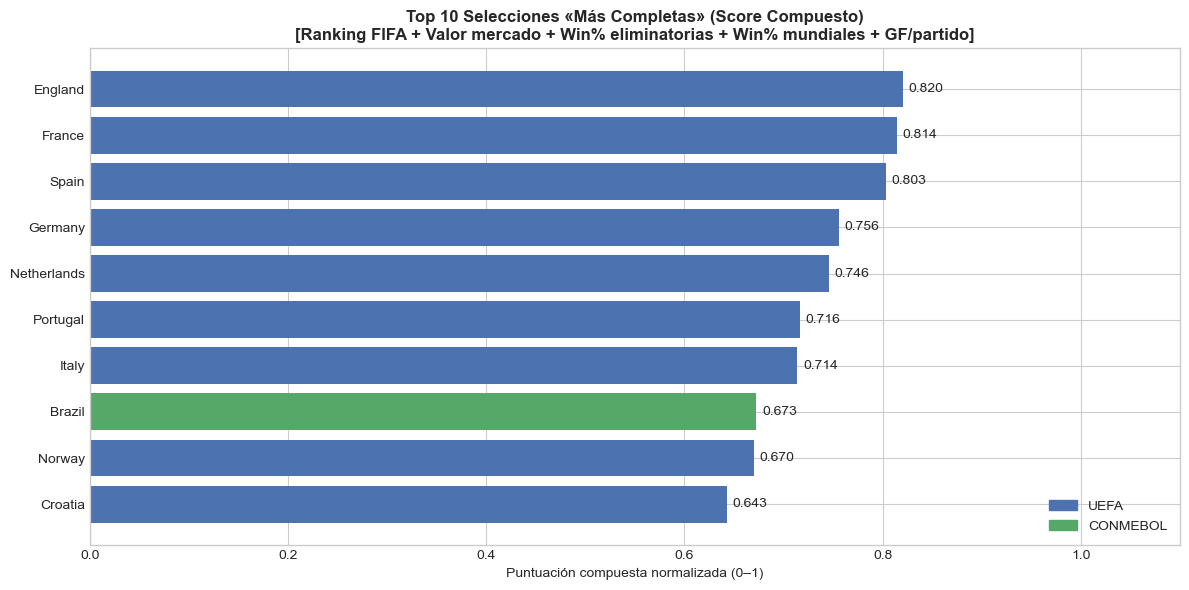

In [45]:
# Ranking compuesto: normalizar métricas clave y promediar
df_score = df_unified.copy()

# ranking_2026: invertir (menor es mejor → normalizar inversamente)
for col, invert in [
    ('ranking_2026',       True),
    ('market_value_eur_m', False),
    ('win_pct_elim',       False),
    ('win_pct_hist',       False),
    ('gf_per_game_elim',   False),
]:
    mn, mx = df_score[col].min(), df_score[col].max()
    if mx > mn:
        norm = (df_score[col] - mn) / (mx - mn)
        df_score[f'norm_{col}'] = (1 - norm) if invert else norm
    else:
        df_score[f'norm_{col}'] = 0

norm_cols = [c for c in df_score.columns if c.startswith('norm_')]
df_score['composite_score'] = df_score[norm_cols].mean(axis=1)

top10_comp = df_score.nlargest(10, 'composite_score')[['nombre_completo','confederacion','composite_score'] + norm_cols]
display(top10_comp.round(3))

# Visualizar
top10_s = df_score.nlargest(10, 'composite_score').sort_values('composite_score')
colors_cs = [CONF_PALETTE.get(c,'#888') for c in top10_s['confederacion']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_s['nombre_completo'], top10_s['composite_score'], color=colors_cs)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Puntuación compuesta normalizada (0–1)')
ax.set_title('Top 10 Selecciones «Más Completas» (Score Compuesto)\n'
             '[Ranking FIFA + Valor mercado + Win% eliminatorias + Win% mundiales + GF/partido]',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
legend_els = [Patch(color=v, label=k) for k,v in CONF_PALETTE.items() if k in top10_s['confederacion'].values]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.show()

**Observaciones (Análisis cruzado):**
- Existe correlación negativa significativa entre valor de mercado y ranking FIFA (mayor valor → mejor posición): esto confirma que el dinero importa en el fútbol moderno.
- La correlación entre ranking FIFA y win% en eliminatorias es moderada, lo que sugiere que el ranking no captura todo el rendimiento clasificatorio.
- La correlación entre win% mundialista histórico y win% en eliminatorias 2026 es positiva pero no perfecta: hay selecciones que han mejorado (o empeorado) respecto a su historia.
- El score compuesto identifica a selecciones con buen balance de valor de mercado, ranking, rendimiento en clasificatoria e historial mundialista.

## 7. Resumen de hallazgos

### Transfermarkt
- El valor de mercado está fuertemente concentrado en UEFA. Las top selecciones (ENG, FRA, ESP) valen más de 10× que las de otras confederaciones.
- La distribución del valor es muy sesgada a la derecha (media >> mediana), lo que indica la presencia de outliers élite.

### Eliminatorias 2026
- NOR, ENG y NZL ganaron el 100% de sus partidos en la fase de grupos. Japón (AFC) también tiene win%=1.0.
- Los equipos *confirmed* tienen win% promedio ~2× mayor al de *playoff*, validando que la clasificación directa discrimina bien la calidad.
- Hay selecciones con excelente ataque pero defensa permeable (cuadrante superior-derecho del scatter GF vs GC).

### Ranking FIFA
- El ranking es relativamente estable para las élites (BRA, ARG, FRA, BEL), con poca volatilidad.
- Algunas selecciones de UEFA (ej. emergentes del este europeo) muestran alta volatilidad, posiblemente por cambios generacionales.

### Historial Mundialista
- El 14% de las 64 selecciones nunca ha jugado un Mundial. Para estas, el torneo de 2026 sería su debut histórico.
- Brasil y Alemania son los reyes históricos, combinando volumen (>100 partidos) con alta eficiencia (>60% victorias).

### Análisis cruzado
- Las tres variables más correlacionadas con el rendimiento general son: **ranking FIFA**, **valor de mercado** y **win% en eliminatorias** — forman el núcleo predictivo del proyecto.
- El score compuesto identifica a **Brasil, Francia, España, Alemania y Argentina** como las selecciones más completas en todas las dimensiones analizadas.